In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [2]:
if not papermill:
    import nci_ipynb, os  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
    
import mkfigs_bootstrap  # noqa: adds external/access-model-mkfigs/src to sys.path (stop-gap)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)

In [3]:
#parameters

### USER EDIT start: this RYF did't save thkcello in rho2!
# esm_file='/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-om3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json
Plot folder path:  /g/data/jk72/fbd581/access-om3-paper-figs/


In [4]:
import xarray as xr
import cf_xarray
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import intake

In [5]:

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)


In [6]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/8787/status


In [7]:
figdir = '/g/data/e14/fbd581/ACCESS-OM3-evaluation/figures/'

### Open the intake-esm datastore

In [8]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [9]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

#### load thkcello (cell thicknmess) in density coordinates and areacello (area at h-points):

In [10]:
thkcello = datastore.search(variable="thkcello", frequency="1mon", variable_cell_methods='area:mean rho2_l:sum yh:mean xh:mean time: mean').to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
)

 areacello is a static field and intake shits himself trying to concatenating it over many files. There must be an easier away to handle this but for now I'm using xarray.opendataset for the sake of simplicity

In [11]:
dg = xr.open_dataset('/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/output000/access-om3.mom6.static.nc')
areacello = dg.areacello
dg.close()

In [12]:
dg = xr.open_dataset('/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/output000/access-om3.mom6.static.nc')
geolon = dg.geolon
geolat = dg.geolat
dg.close()

### Calculation of rho*Dv global integral:

In [13]:
# 1. compute volume per density class

# Broadcast areacello onto thkcello grid
dV = thkcello.thkcello * areacello
# Global volume in each density layer
V_rho = dV.sum(dim=["yh", "xh"])

# 2. compute layer mass
M_rho = V_rho * thkcello.rho2_l

# 3. Total ocean mass
M_total = M_rho.isel(time=0).sum("rho2_l")

# 4. Water mass changes relative to initial monthly output
dM = M_rho - M_rho.isel(time=0)

# 5. Normalisation by total ocean mass
dM_norm = dM / M_total

In [14]:
# %%time

# dM_norm.load()

In [15]:
# fig, ax = plt.subplots(figsize=(12,6))

# dM_norm.T.plot(
#     ax=ax,
#     x="time",
#     y="rho2_l",
#     cmap="RdBu_r",
#     robust=True,
#     cbar_kwargs={
#         "label": r"Normalised water mass changes"
#     }
# )

# ax.invert_yaxis()  # optional
# ax.set_ylim(1037.5,1033.) 
# ax.set_ylabel(r"$\sigma_2$ (kg m$^{-3}$)")

# plt.show()

### Doing regional plots

In [16]:

regions = { # [minx, maxx, miny, maxy], using model longitude range (-280 to 80)
    "Global": [-280, 80, -90, 90],
    "Arctic": [-280, 80, 65, 90],
    "Southern Ocean": [-280, 80, -82, -63],
    "ACC": [-280, 80, -63, -45],
    "Southern Pacific": [-210, -70, -45, -20],
    "Tropical Pacific": [-240, -100, -20, 20],
    "North Pacific": [-240, -100, 20, 65],
    "South Atlantic": [-60, 20, -45, -20],
    "Tropical Atlantic": [-70, 20, -20, 20],
    "North Atlantic": [-100, 0, 20, 65],
    "Indian": [30, -240, -45, 20],
    # "Indian": [30, 80, -45, 20], #"Indian": [30, 120, -45, 20],
    # "Aegean Sea": [18, 27.5, 34, 44],
    # "Black Sea": [27.5, 43, 40.5, 48],
    # "Baltic Sea": [13, 30, 53, 58],
    # "Mediterranean Sea": [0, 35, 31, 41],
    # "Red Sea": [33, 44, 12, 29],
    # "Persian Gulf": [47, 56, 24, 31],
    # "White Sea": [31, 41, 63, 68],
}

regions = {k: dict(zip(["minx", "maxx", "miny", "maxy"], v)) for k, v in regions.items()}  # convert to dicts

for r, d in regions.items():
    for k, x in d.items():
        if k in ["minx", "maxx"] and x != max(-280, min(x, 80)):
            raise ValueError(f"{r} {k} = {x} is outside the range -280 to 80")



In [17]:

results = {}

for region, bounds in regions.items():

    # Create regional mask

    if bounds["minx"] <= bounds["maxx"]:
        mask_lon = (
            (geolon >= bounds["minx"]) &
            (geolon <= bounds["maxx"])
        )
    else:
        mask_lon = (
            (geolon >= bounds["minx"]) |
            (geolon <= bounds["maxx"])
        )
        
    mask = (
        mask_lon &
        (geolat >= bounds["miny"]) &
        (geolat <= bounds["maxy"])
    )


    # Apply mask
    thk_reg = thkcello.where(mask)
    area_reg = areacello.where(mask)

    # 1. volume per density class
    dV = thk_reg.thkcello * area_reg
    V_rho = dV.sum(dim=["yh", "xh"])

    # 2. layer mass
    M_rho = V_rho * thk_reg.rho2_l

    # 3. total regional mass
    M_total = M_rho.isel(time=0).sum("rho2_l")

    # 4. anomaly relative to first month
    dM = M_rho - M_rho.isel(time=0)

    # 5. normalize
    dM_norm = dM / M_total

    results[region] = dM_norm

In [18]:
len(results)

11

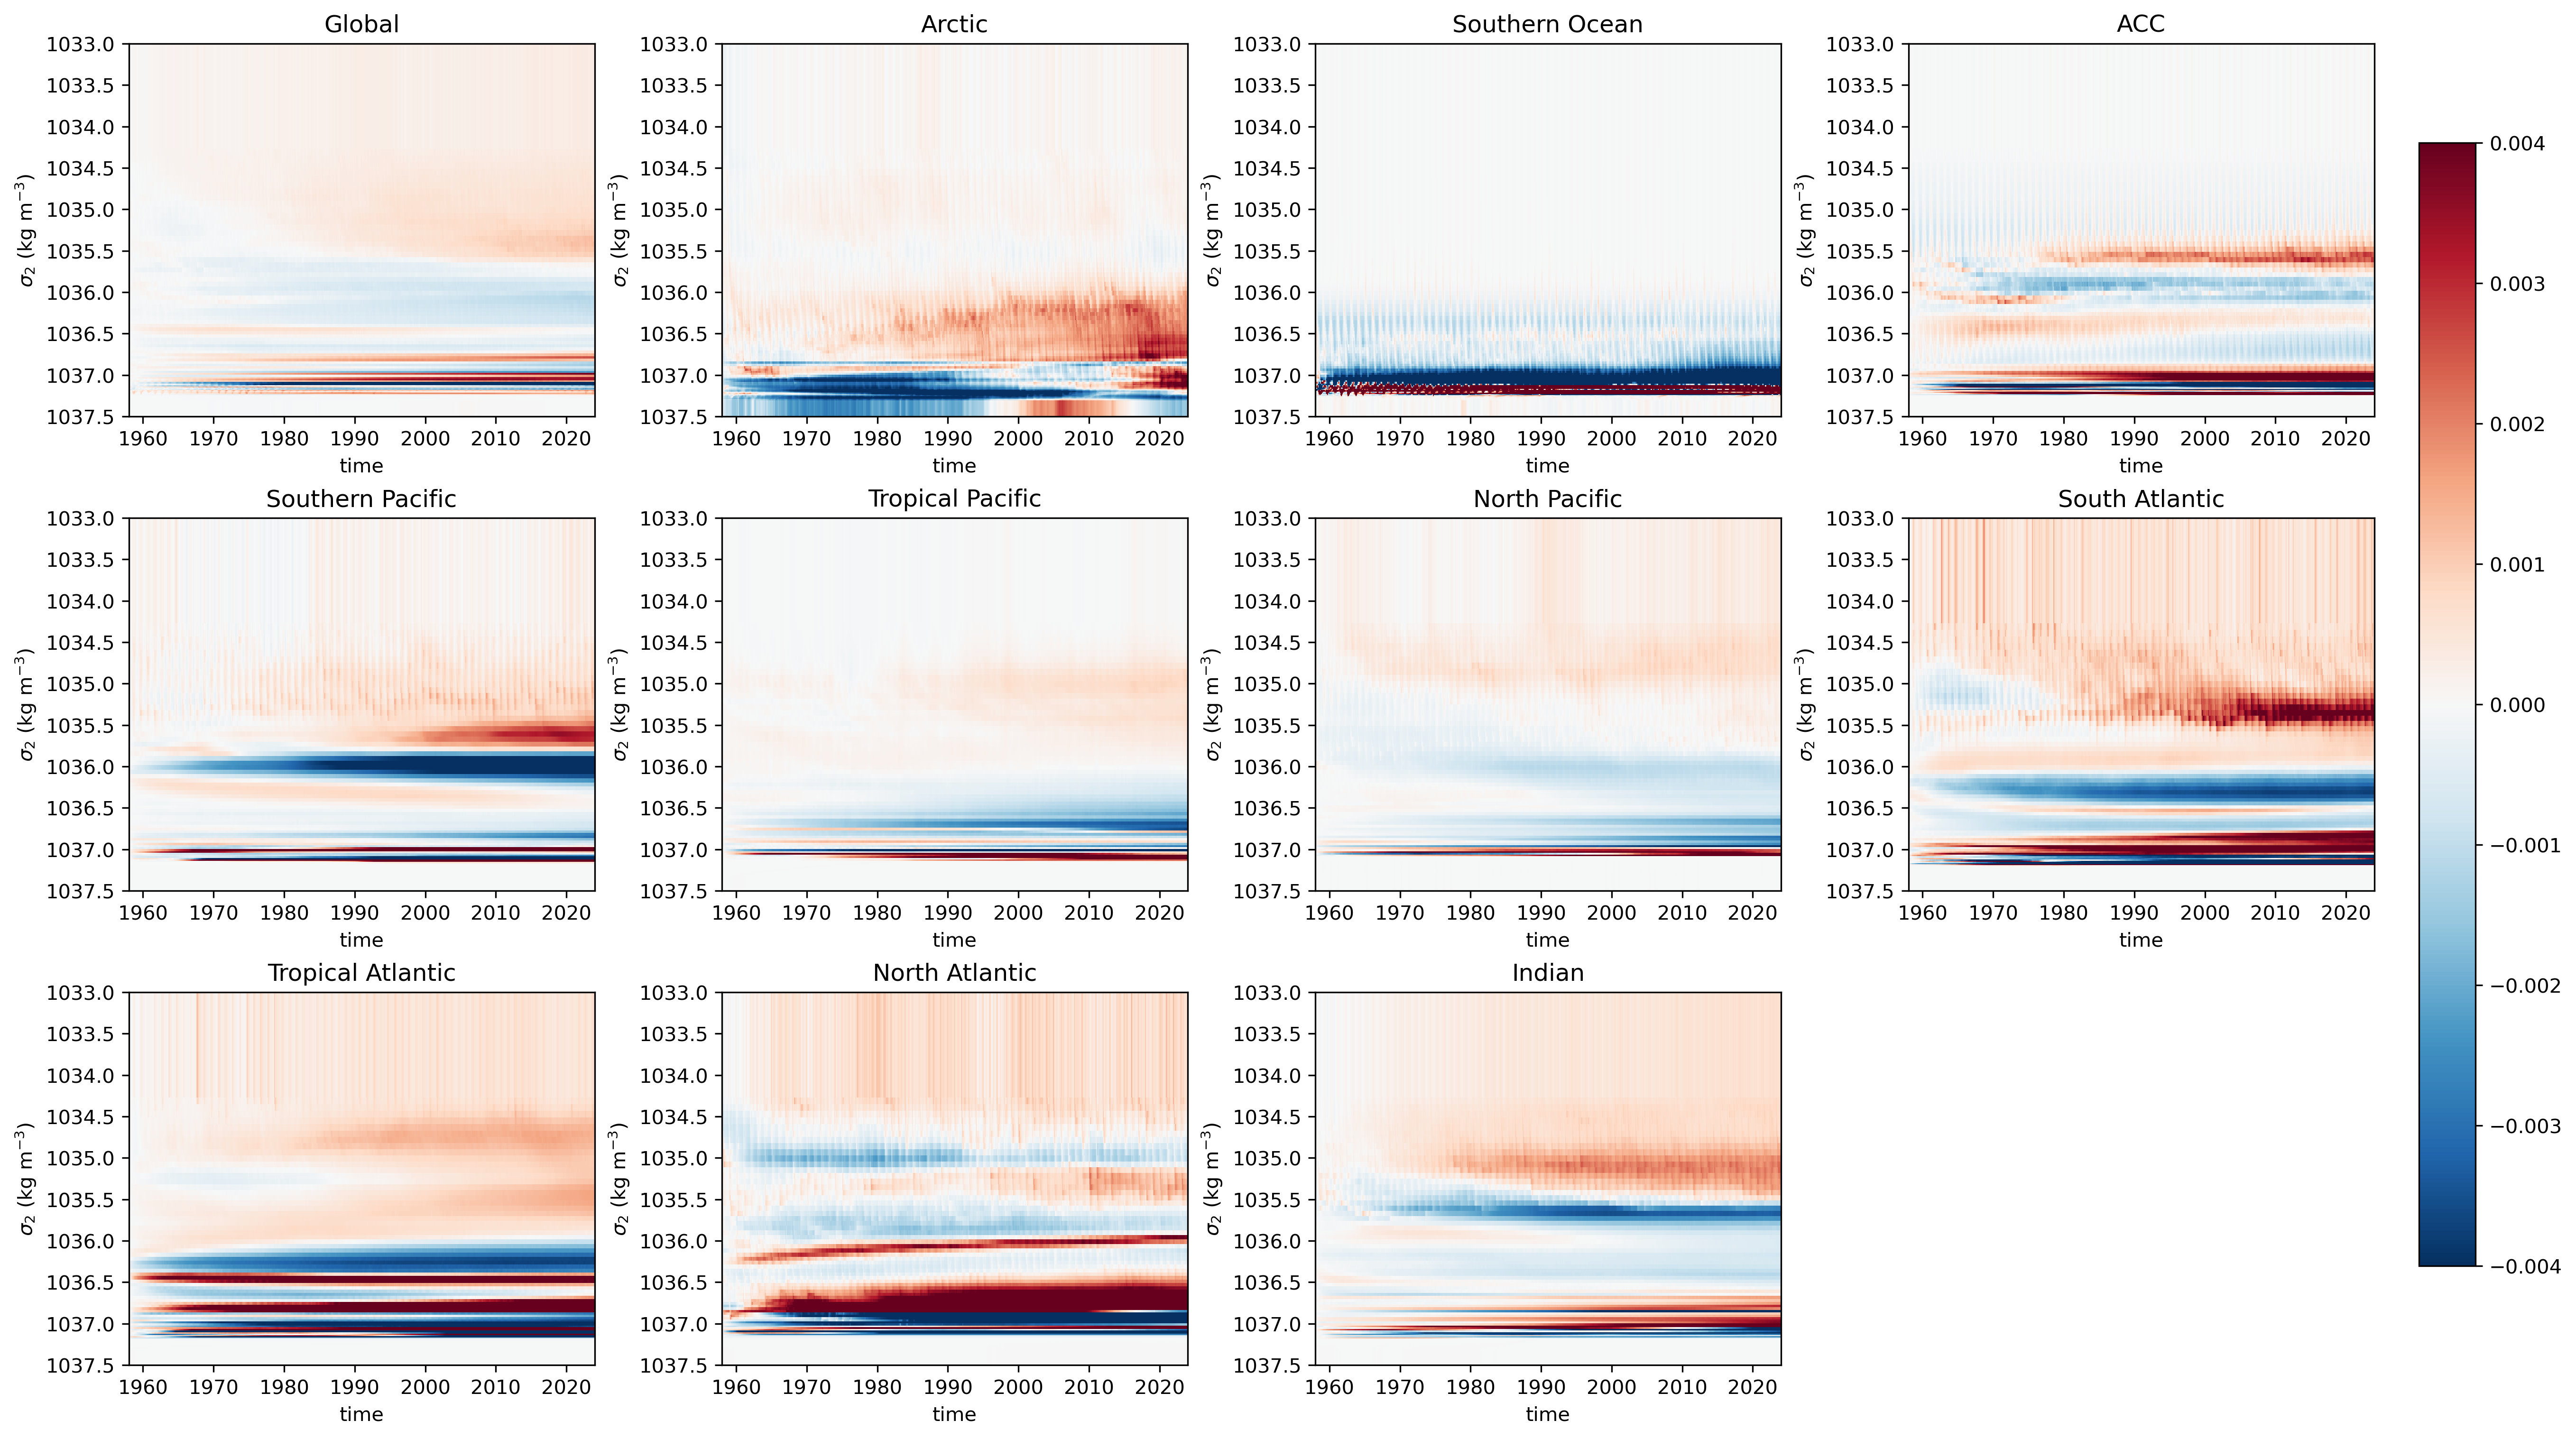

In [23]:
fig, axs = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 10),
    constrained_layout=True
)

axs = axs.ravel()

for ax, (region, dM_norm) in zip(axs, results.items()):

    pcm =dM_norm.T.plot(
        ax=ax,
        x="time",
        y="rho2_l",        
        vmin=-0.004,
        vmax=0.004,
        cmap="RdBu_r",
        # robust=True,
        add_colorbar=False
    )

    ax.invert_yaxis()
    ax.set_ylim(1037.5, 1033.)
    ax.set_title(region)
    ax.set_ylabel(r"$\sigma_2$ (kg m$^{-3}$)")

# Hide unused subplot(s)
for ax in axs[len(results):]:
    ax.set_visible(False)

# Shared colorbar
cbar = fig.colorbar(
    pcm,
    ax=axs[:len(results)],
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)

mkmd.savefig(fig,"Water mass density change Hovmoller",
             "ACCESS-OM3 WM density change", dpi=150)
plt.show()

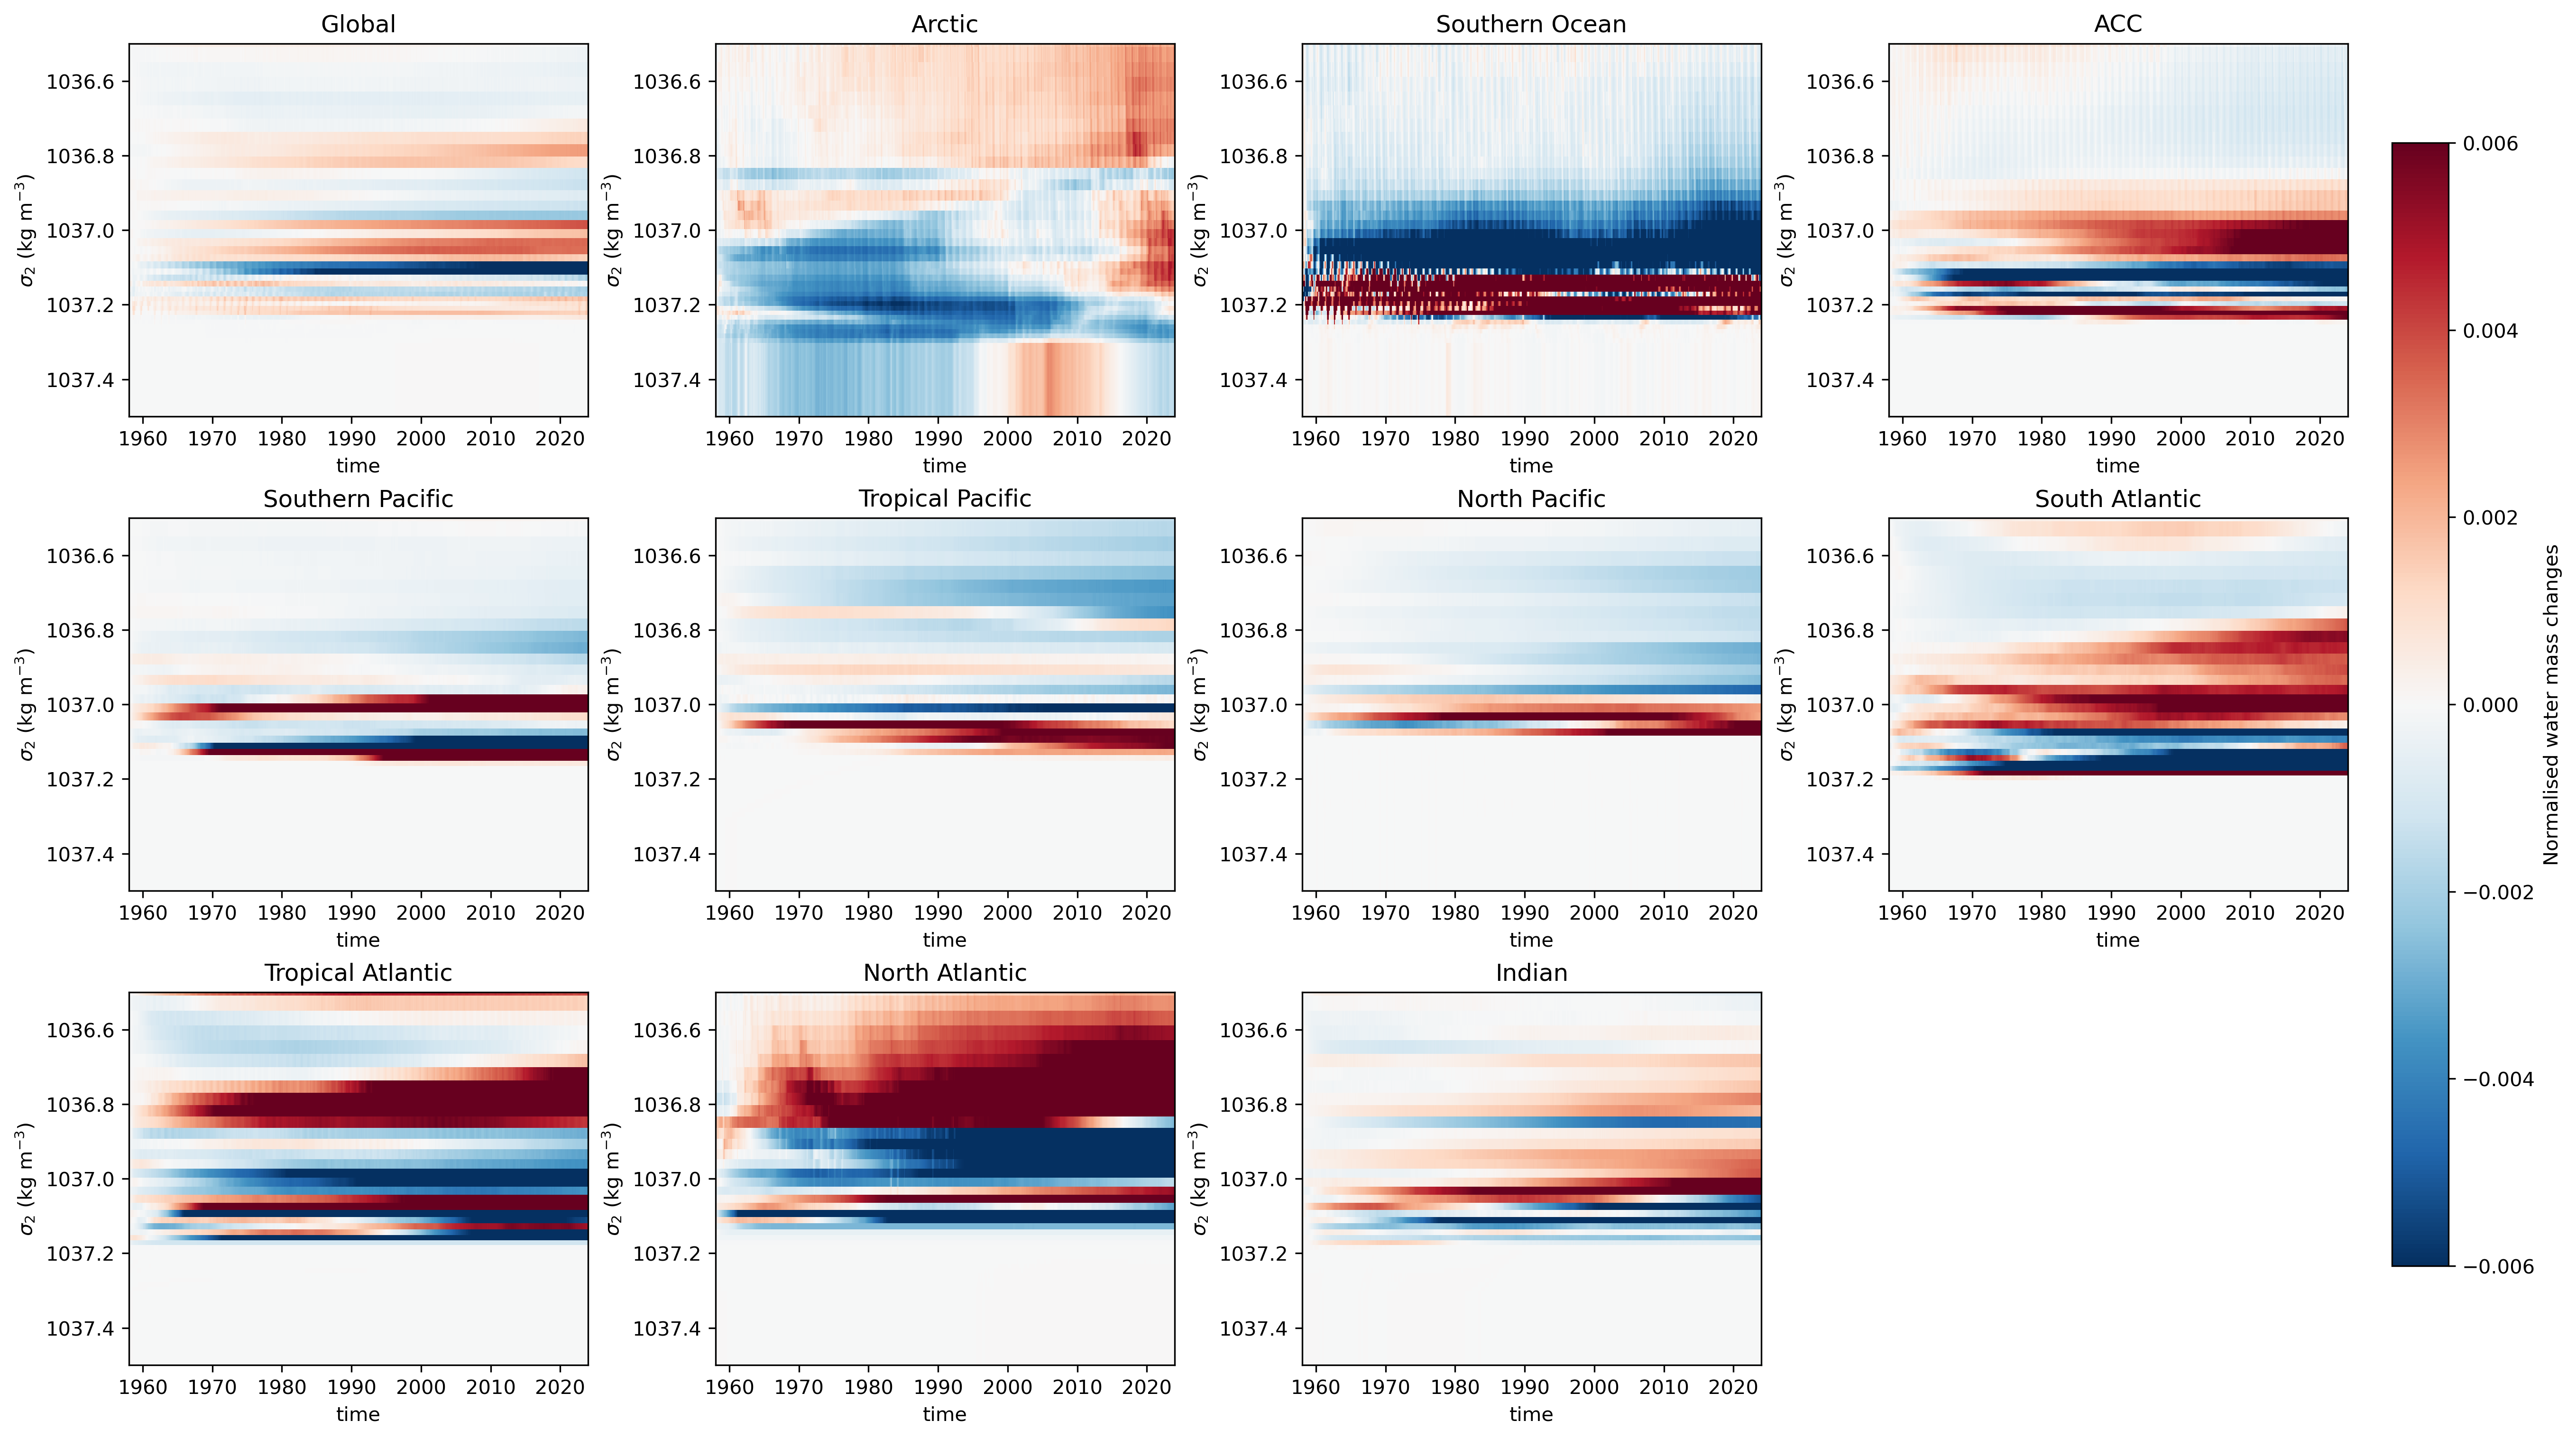

In [24]:
fig, axs = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(18, 10),
    constrained_layout=True
)

axs = axs.ravel()

for ax, (region, dM_norm) in zip(axs, results.items()):

    pcm =    dM_norm.T.plot(
        ax=ax,
        x="time",
        y="rho2_l",
        vmin=-0.006,
        vmax=0.006,
        cmap="RdBu_r",
        add_colorbar=False
    )

    ax.invert_yaxis()
    ax.set_ylim(1037.5, 1036.5)
    ax.set_title(region)
    ax.set_ylabel(r"$\sigma_2$ (kg m$^{-3}$)")

for ax in axs[len(results):]:
    ax.set_visible(False)

cbar = fig.colorbar(
    pcm,
    ax=axs[:len(results)],
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)

cbar.set_label("Normalised water mass changes")

mkmd.savefig(fig,"Water mass density change Hovmoller - Dense Waters only",
             "ACCESS-OM3 Dense WM density change", dpi=150)
plt.show()